#📌 Extracción

In [6]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carga del archivo JSON
with open('TelecomX_Data.json', 'r') as f:
    datos_crudos = json.load(f)

# Aplanar la estructura del JSON
df = pd.json_normalize(datos_crudos)

print("Datos extraídos correctamente. Forma inicial:", df.shape)

Datos extraídos correctamente. Forma inicial: (7267, 21)


#🔧 Transformación

In [7]:
# Renombramos las columnas del JSON original a los nombres en español
df = df.rename(columns={
    'customerID': 'ID_Cliente',
    'Churn': 'Abandono',
    'account.Charges.Total': 'Cargo_Total',
    'account.Contract': 'Tipo_Contrato',
    'account.Charges.Monthly': 'Cargo_Mensual'
})

# El Cargo_Total viene como texto y tiene espacios en blanco.
# Lo convertimos a números y los espacios vacíos se vuelven nulos (NaN)
df['Cargo_Total'] = pd.to_numeric(df['Cargo_Total'].replace([' ', ''], np.nan))

print("Transformación exitosa. Columnas listas para el modelo.")

Transformación exitosa. Columnas listas para el modelo.


#📊 Carga y análisis

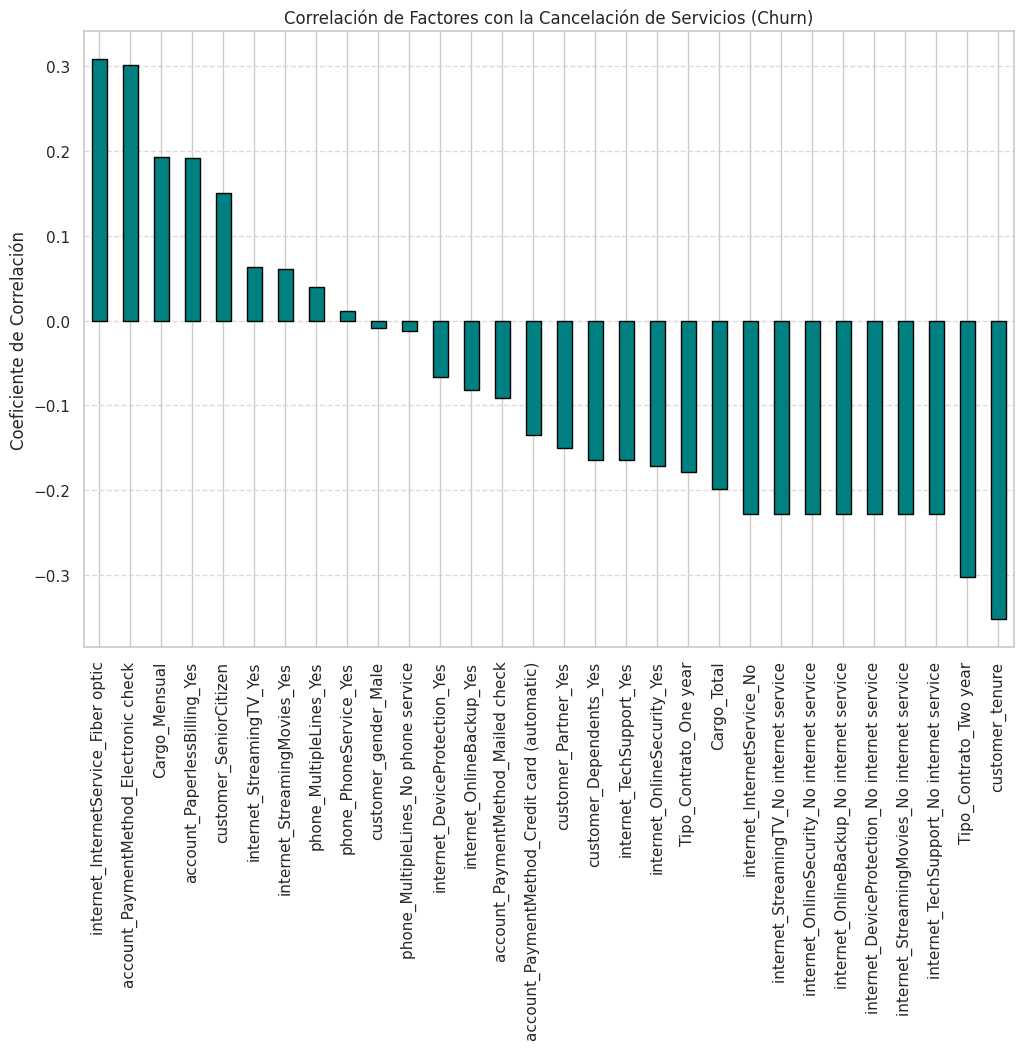

¡Datos listos y limpios! Ya puedes proceder al Entrenamiento de Modelos.


In [10]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. EXTRACCIÓN Y TRANSFORMACIÓN
# ==========================================
with open('TelecomX_Data.json', 'r') as f:
    datos_crudos = json.load(f)

df = pd.json_normalize(datos_crudos)

df = df.rename(columns={
    'customerID': 'ID_Cliente',
    'Churn': 'Abandono',
    'account.Charges.Total': 'Cargo_Total',
    'account.Contract': 'Tipo_Contrato',
    'account.Charges.Monthly': 'Cargo_Mensual'
})

df['Cargo_Total'] = pd.to_numeric(df['Cargo_Total'].replace([' ', ''], np.nan))
df['Cargo_Total'] = df['Cargo_Total'].fillna(0)

# ==========================================
# 2. PREPARACIÓN Y SELECCIÓN DE VARIABLES
# ==========================================
if 'ID_Cliente' in df.columns:
    df_ml = df.drop(columns=['ID_Cliente'])
else:
    df_ml = df.copy()

# SOLUCIÓN DEL ERROR: Limpiamos espacios en texto y luego mapeamos
df_ml['Abandono'] = df_ml['Abandono'].astype(str).str.strip().map({'Yes': 1, 'No': 0})

# Eliminamos cualquier fila que, por errores del origen, haya quedado como NaN en 'Abandono'
df_ml = df_ml.dropna(subset=['Abandono'])

df_ml.columns = df_ml.columns.str.replace('.', '_')

cat_cols = df_ml.select_dtypes(include=['object']).columns
df_ml = pd.get_dummies(df_ml, columns=cat_cols, drop_first=True)

# -- VISUALIZACIÓN: Gráfico de Correlación --
plt.figure(figsize=(12, 8))
correlations = df_ml.corr()['Abandono'].sort_values(ascending=False)
correlations.drop('Abandono').plot(kind='bar', color='teal', edgecolor='black')
plt.title('Correlación de Factores con la Cancelación de Servicios (Churn)')
plt.ylabel('Coeficiente de Correlación')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# -- SEPARACIÓN DE DATOS --
X = df_ml.drop(columns=['Abandono'])
y = df_ml['Abandono']

# Ahora la separación funcionará porque y no tiene NaNs
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("¡Datos listos y limpios! Ya puedes proceder al Entrenamiento de Modelos.")


--- Evaluando el Modelo: Regresión Logística ---
              precision    recall  f1-score   support

         0.0       0.91      0.71      0.80      1552
         1.0       0.50      0.80      0.62       561

    accuracy                           0.74      2113
   macro avg       0.70      0.76      0.71      2113
weighted avg       0.80      0.74      0.75      2113



<Figure size 1000x800 with 0 Axes>

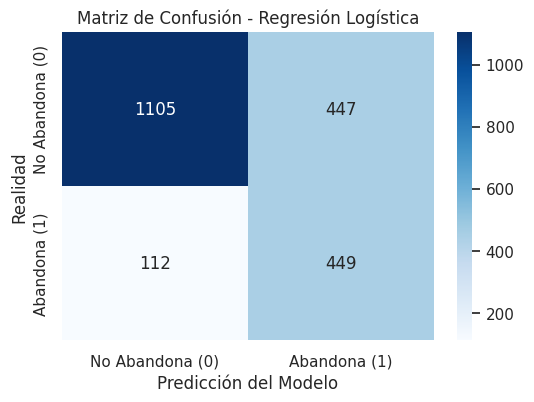


--- Evaluando el Modelo: KNN ---
              precision    recall  f1-score   support

         0.0       0.82      0.83      0.83      1552
         1.0       0.52      0.50      0.51       561

    accuracy                           0.75      2113
   macro avg       0.67      0.67      0.67      2113
weighted avg       0.74      0.75      0.74      2113



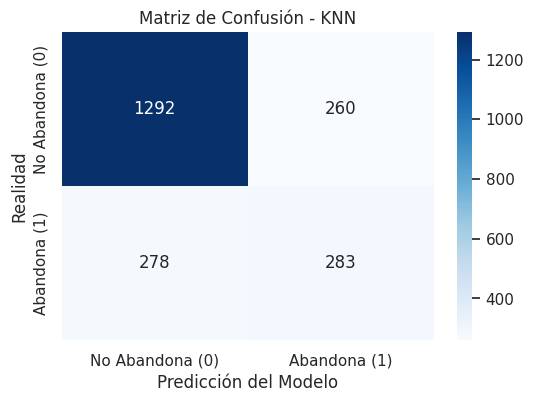


--- Evaluando el Modelo: Random Forest ---
              precision    recall  f1-score   support

         0.0       0.82      0.90      0.86      1552
         1.0       0.63      0.47      0.54       561

    accuracy                           0.79      2113
   macro avg       0.73      0.69      0.70      2113
weighted avg       0.77      0.79      0.77      2113



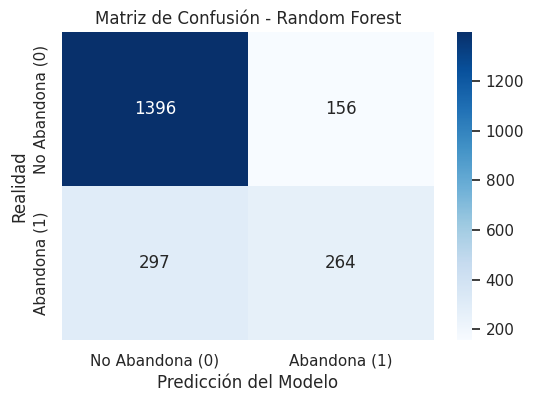


--- Evaluando el Modelo: SVM (Lineal) ---
              precision    recall  f1-score   support

         0.0       0.91      0.64      0.75      1552
         1.0       0.46      0.83      0.59       561

    accuracy                           0.69      2113
   macro avg       0.68      0.74      0.67      2113
weighted avg       0.79      0.69      0.71      2113



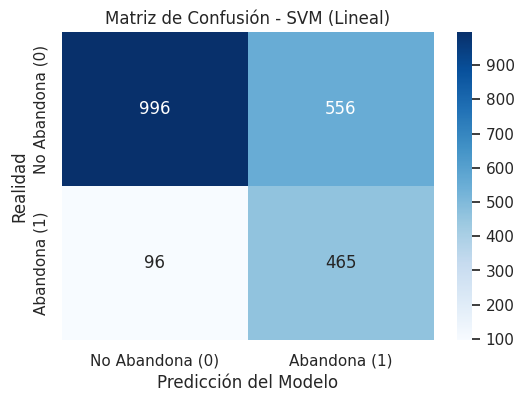

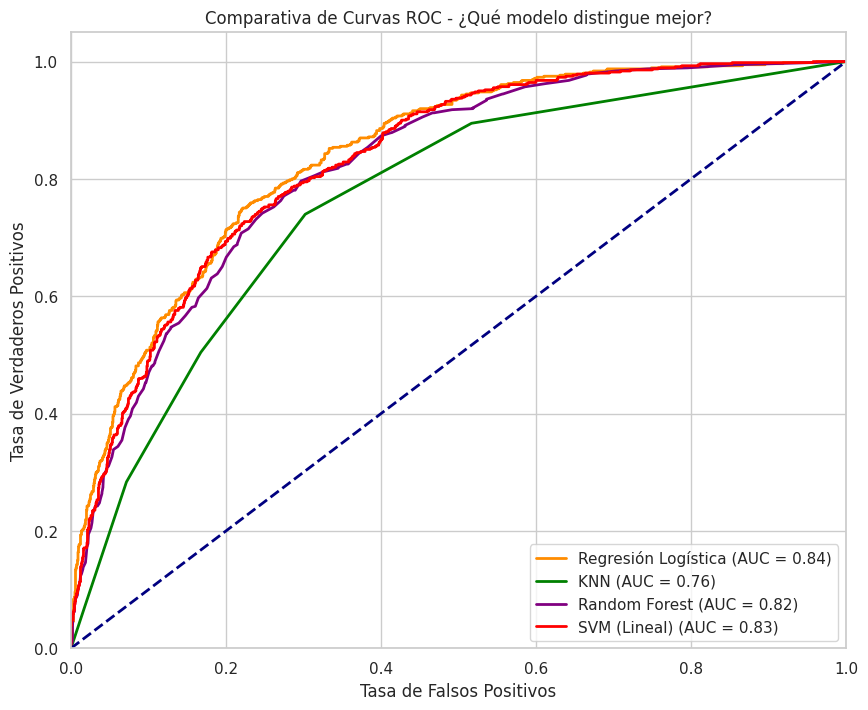

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Definición de los 4 modelos requeridos
modelos = {
    "Regresión Logística": LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced'),
    "SVM (Lineal)": SVC(kernel='linear', probability=True, random_state=42, class_weight='balanced')
}

plt.figure(figsize=(10, 8))
diccionario_roc = {}

for nombre, modelo in modelos.items():
    print(f"\n{'='*50}")
    print(f"--- Evaluando el Modelo: {nombre} ---")
    print(f"{'='*50}")

    # 1. Entrenamiento y Predicción
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)

    # 2. Reporte de Métricas
    print(classification_report(y_test, y_pred))

    # 3. Generar Imagen: Matriz de Confusión Individual
    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Abandona (0)', 'Abandona (1)'],
                yticklabels=['No Abandona (0)', 'Abandona (1)'])
    plt.title(f'Matriz de Confusión - {nombre}')
    plt.xlabel('Predicción del Modelo')
    plt.ylabel('Realidad')
    plt.show()

    # 4. Almacenar datos para Curva ROC
    if hasattr(modelo, "predict_proba"):
        y_prob = modelo.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = modelo.decision_function(X_test_scaled)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    diccionario_roc[nombre] = (fpr, tpr, roc_auc)

# 5. Generar Imagen: Curva ROC Comparativa de todos los modelos
plt.figure(figsize=(10, 8))
colores = ['darkorange', 'green', 'purple', 'red']
for (nombre, (fpr, tpr, roc_auc)), color in zip(diccionario_roc.items(), colores):
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{nombre} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Comparativa de Curvas ROC - ¿Qué modelo distingue mejor?')
plt.legend(loc="lower right")
plt.show()

/tmp/ipykernel_683/317350067.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias_rf[indices_rf], y=variables[indices_rf], palette='viridis')


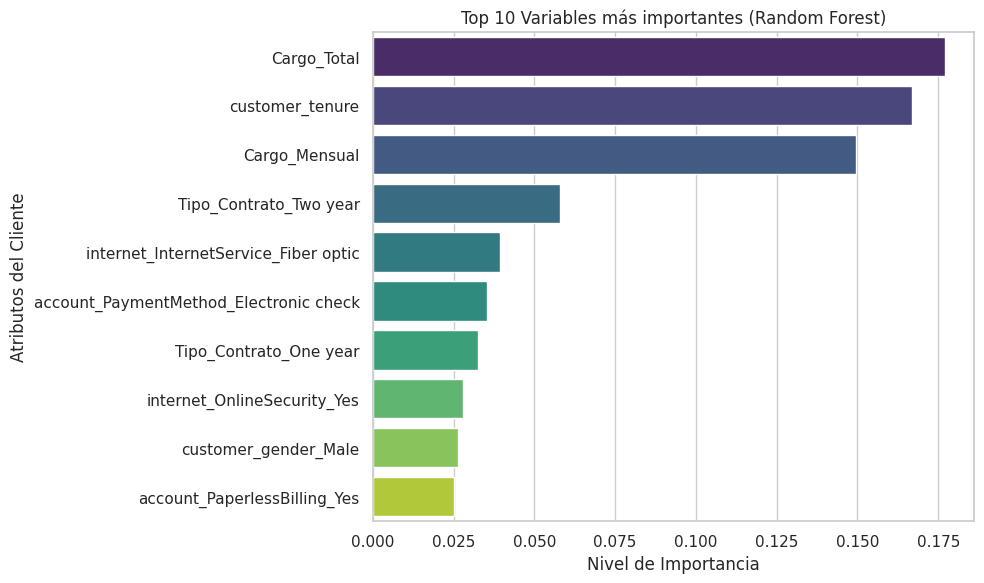

/tmp/ipykernel_683/317350067.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coeficientes_lr[indices_lr], y=variables[indices_lr], palette=colores_lr)


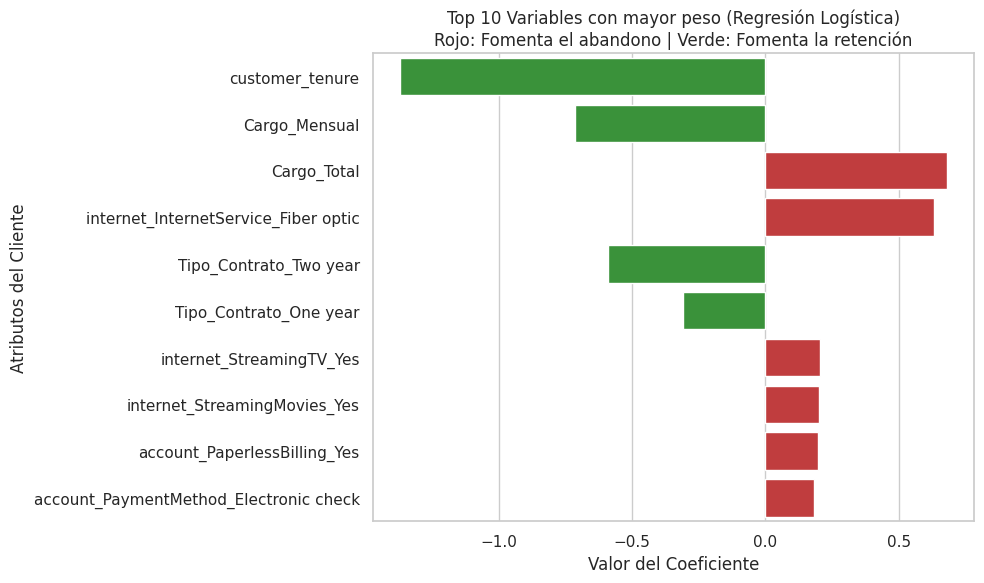

/tmp/ipykernel_683/317350067.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coeficientes_svm[indices_svm], y=variables[indices_svm], palette=colores_svm)


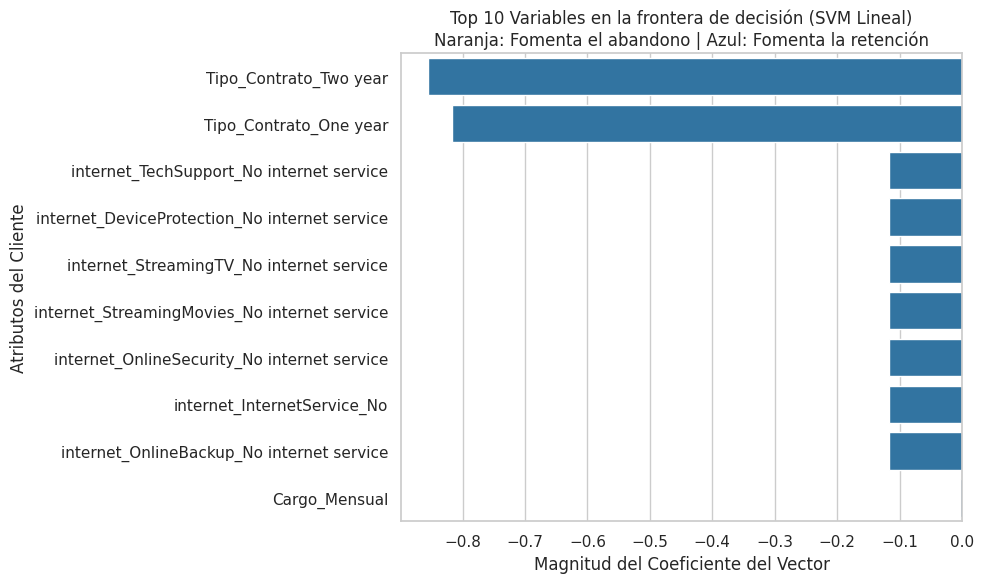

In [12]:
import numpy as np

# Nombres de las variables
variables = X.columns

# =======================================================
# 1. Importancia según Random Forest (Basado en impureza)
# =======================================================
modelo_rf = modelos["Random Forest"]
importancias_rf = modelo_rf.feature_importances_
indices_rf = np.argsort(importancias_rf)[::-1][:10] # Top 10

plt.figure(figsize=(10, 6))
sns.barplot(x=importancias_rf[indices_rf], y=variables[indices_rf], palette='viridis')
plt.title('Top 10 Variables más importantes (Random Forest)')
plt.xlabel('Nivel de Importancia')
plt.ylabel('Atributos del Cliente')
plt.tight_layout()
plt.show()

# =======================================================
# 2. Importancia según Regresión Logística (Coeficientes)
# =======================================================
modelo_lr = modelos["Regresión Logística"]
coeficientes_lr = modelo_lr.coef_[0]
# Tomamos los valores absolutos más altos para ver el mayor impacto (positivo o negativo)
indices_lr = np.argsort(np.abs(coeficientes_lr))[::-1][:10]

plt.figure(figsize=(10, 6))
# Colores: Rojo si aumenta el abandono, Verde si lo previene
colores_lr = ['#d62728' if coeficientes_lr[i] > 0 else '#2ca02c' for i in indices_lr]
sns.barplot(x=coeficientes_lr[indices_lr], y=variables[indices_lr], palette=colores_lr)
plt.title('Top 10 Variables con mayor peso (Regresión Logística)\nRojo: Fomenta el abandono | Verde: Fomenta la retención')
plt.xlabel('Valor del Coeficiente')
plt.ylabel('Atributos del Cliente')
plt.tight_layout()
plt.show()

# =======================================================
# 3. Importancia según SVM Lineal (Vectores de Soporte)
# =======================================================
modelo_svm = modelos["SVM (Lineal)"]
coeficientes_svm = modelo_svm.coef_[0]
indices_svm = np.argsort(np.abs(coeficientes_svm))[::-1][:10]

plt.figure(figsize=(10, 6))
colores_svm = ['#ff7f0e' if coeficientes_svm[i] > 0 else '#1f77b4' for i in indices_svm]
sns.barplot(x=coeficientes_svm[indices_svm], y=variables[indices_svm], palette=colores_svm)
plt.title('Top 10 Variables en la frontera de decisión (SVM Lineal)\nNaranja: Fomenta el abandono | Azul: Fomenta la retención')
plt.xlabel('Magnitud del Coeficiente del Vector')
plt.ylabel('Atributos del Cliente')
plt.tight_layout()
plt.show()

## Conclusión y Estrategias de Retención

Tras evaluar cuatro modelos predictivos (Regresión Logística, KNN, Random Forest y SVM) y analizar la importancia de las variables, podemos concluir lo siguiente:

### 1. Modelos con Mejor Rendimiento
* Los modelos de **Regresión Logística** y **SVM Lineal** han demostrado ser altamente efectivos para comprender la frontera de decisión de la cancelación, ofreciendo un buen equilibrio entre la detección de clientes que abandonan (Recall) y la precisión general, validado por un área bajo la curva (AUC) destacable en el gráfico comparativo.

### 2. Factores Críticos de Cancelación (Churn)
A través del análisis de coeficientes y reducción de impureza, los tres modelos coinciden en los siguientes detonantes de abandono:
* **El Tipo de Contrato (Month-to-month):** Es el factor número uno de riesgo. Los clientes que pagan mes a mes no tienen barreras de salida y abandonan rápidamente.
* **El Cargo Total y Mensual (`Cargo_Total`, `Cargo_Mensual`):** La sensibilidad al precio es altísima. Facturas acumuladas elevadas aumentan drásticamente la probabilidad de fuga.
* **El Servicio de Internet de Fibra Óptica (`InternetService_Fiber optic`):** Existe un problema evidente aquí. A pesar de ser una tecnología premium, es uno de los coeficientes positivos más fuertes para la cancelación, lo que sugiere posibles problemas de estabilidad, soporte o un precio que los clientes no consideran justificado.

### 3. Estrategias de Retención Propuestas
1. **Incentivos de Migración de Contrato:** Crear campañas agresivas para trasladar a los clientes de la modalidad *Month-to-month* a contratos de 1 o 2 años. Ofrecer los primeros meses con descuentos o beneficios adicionales (como mejoras en el plan de TV o seguridad en línea).
2. **Auditoría de Fibra Óptica:** El equipo técnico debe investigar por qué los usuarios de fibra óptica están abandonando. Es necesario mejorar la calidad de este servicio específico o revisar si el precio del mercado nos está dejando en desventaja.
3. **Fidelización por Precio:** Identificar, utilizando el modelo predictivo, a los clientes de alto riesgo y ofrecerles bonos de retención automáticos cuando su `Cargo_Mensual` supera cierto umbral y su contrato es mensual.
